In [16]:
# tutorial de https://www.geeksforgeeks.org/python/working-csv-files-python/

import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib.ticker import FuncFormatter,StrMethodFormatter
import glob
import os
import numpy as np
import seaborn as sns

In [17]:
def getData(ruta):
    patronArchivos = os.path.join(ruta, "*.csv") # string con formato ruta/*.csv
    archivos = glob.glob(patronArchivos) #encuentra todo lo que matchea el patrón
    
    archivos = sorted(archivos)
    promedios = np.zeros(len(archivos))
    
    
    for i, archivo in enumerate(archivos):
        tempDf = pd.read_csv(archivo,
                             sep = ';',
                             decimal = ',',
                             encoding='latin-1')
                            
    
        
    return tempDf

In [18]:
def graficar(datos):

    lugares = datos['UBICACIÓN'].unique()

    # Crea un nuevo DataFrame solo con esas filas
    resultado = datos[datos['UBICACIÓN'] == '150']
    


    # 1. Convertir fecha y ordenar
    datos['FECHA'] = pd.to_datetime(datos['FECHA'], dayfirst=True)
    datos = datos.sort_values('FECHA')
    
    # 2. Configurar la figura (2 filas, 2 columnas)
    fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
    ubicacion = datos['UBICACIÓN'].iloc[0]
    fig.suptitle(f'Análisis de Variables para Ubicación: {ubicacion}', fontsize=16)
    
    # 3. Graficar cada variable
    # Cloro
    axs[0, 0].plot(datos['FECHA'], datos['CLORO'], marker='o', color='blue')
    axs[0, 0].set_title('Cloro')
    axs[0, 0].set_ylabel('mg/l')
    axs[0, 0].set_ylim(0, 1)
    
    # Turbiedad
    axs[0, 1].plot(datos['FECHA'], datos['TURBIEDAD'], marker='s', color='orange')
    axs[0, 1].set_title('Turbiedad')
    axs[0, 1].set_ylabel('NTU')
    axs[0, 1].set_ylim(0, 1.2)
    
    # pH
    axs[1, 0].plot(datos['FECHA'], datos['PH'], marker='^', color='green')
    axs[1, 0].set_title('pH')
    axs[1, 0].set_ylabel('Unidades pH')
    axs[1, 0].set_ylim(5.5, 8)
    
    # Temperatura
    axs[1, 1].plot(datos['FECHA'], datos['TEMPERATURA'], marker='x', color='red')
    axs[1, 1].set_title('Temperatura')
    axs[1, 1].set_ylabel('°C')
    axs[1, 1].set_ylim(15, 24)
    
    # Formato estético
    for ax in axs.flat:
        ax.grid(True, linestyle='--', alpha=0.6)
    
    plt.xticks(rotation=45)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
        


    

In [22]:
def graficarCajas(df):

    # 1. Configuración de datos y variables
    lugares = df['UBICACIÓN'].unique()
    variables = ['CLORO', 'TURBIEDAD', 'PH', 'TEMPERATURA']
    unidades = ['mg/l', 'NTU', 'pH', '°C']

    
    
    # 2. Crear la figura
    fig, axs = plt.subplots(len(lugares), 4, figsize=(18, 5 * len(lugares)), squeeze=False)
    
    for i, loc in enumerate(lugares):
        df_loc = df[df['UBICACIÓN'] == loc]
        
        for j, var in enumerate(variables):
            ax = axs[i, j]
            data_var = df_loc[var].dropna()
            
            # --- Cálculo de métricas ---
            resumen = data_var.describe()
            promedio = resumen['mean']
            v_max = resumen['max']
            v_min = resumen['min']
            
            # Cálculo de Outliers (IQR)
            q1 = resumen['25%']
            q3 = resumen['75%']
            iqr = q3 - q1
            bajo = q1 - 1.5 * iqr
            alto = q3 + 1.5 * iqr
            outliers = data_var[(data_var < bajo) | (data_var > alto)]
            pct_outliers = (len(outliers) / len(data_var)) * 100 if len(data_var) > 0 else 0
    
            # --- Gráfico con Seaborn ---
            sns.boxplot(y=data_var, ax=ax, color='skyblue', width=0.5, showmeans=True,
                        meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})
            sns.stripplot(y=data_var, ax=ax, color='black', alpha=0.3)
    
            # --- Anotaciones de texto ---
            texto_stats = (f'Media: {promedio:.2f}\n'
                           f'Máx: {v_max:.2f}\n'
                           f'Mín: {v_min:.2f}\n'
                           f'Outliers: {pct_outliers:.1f}%')
            
            # Colocamos el texto a la derecha del boxplot
            ax.text(1.1, 0.5, texto_stats, transform=ax.transAxes, 
                    fontsize=10, verticalalignment='center', 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    
            # Títulos y etiquetas
            if i == 0: ax.set_title(f'{var}', fontsize=14, fontweight='bold')
            ax.set_ylabel(unidades[j] if j == 0 else "")
            if j == 0: ax.set_xlabel(f'Ubicación {loc}', fontweight='bold')
    
    plt.tight_layout(rect=[0, 0, 0.9, 1]) # Espacio para las etiquetas de la derecha
    plt.show()

In [23]:
datos=getData('./')


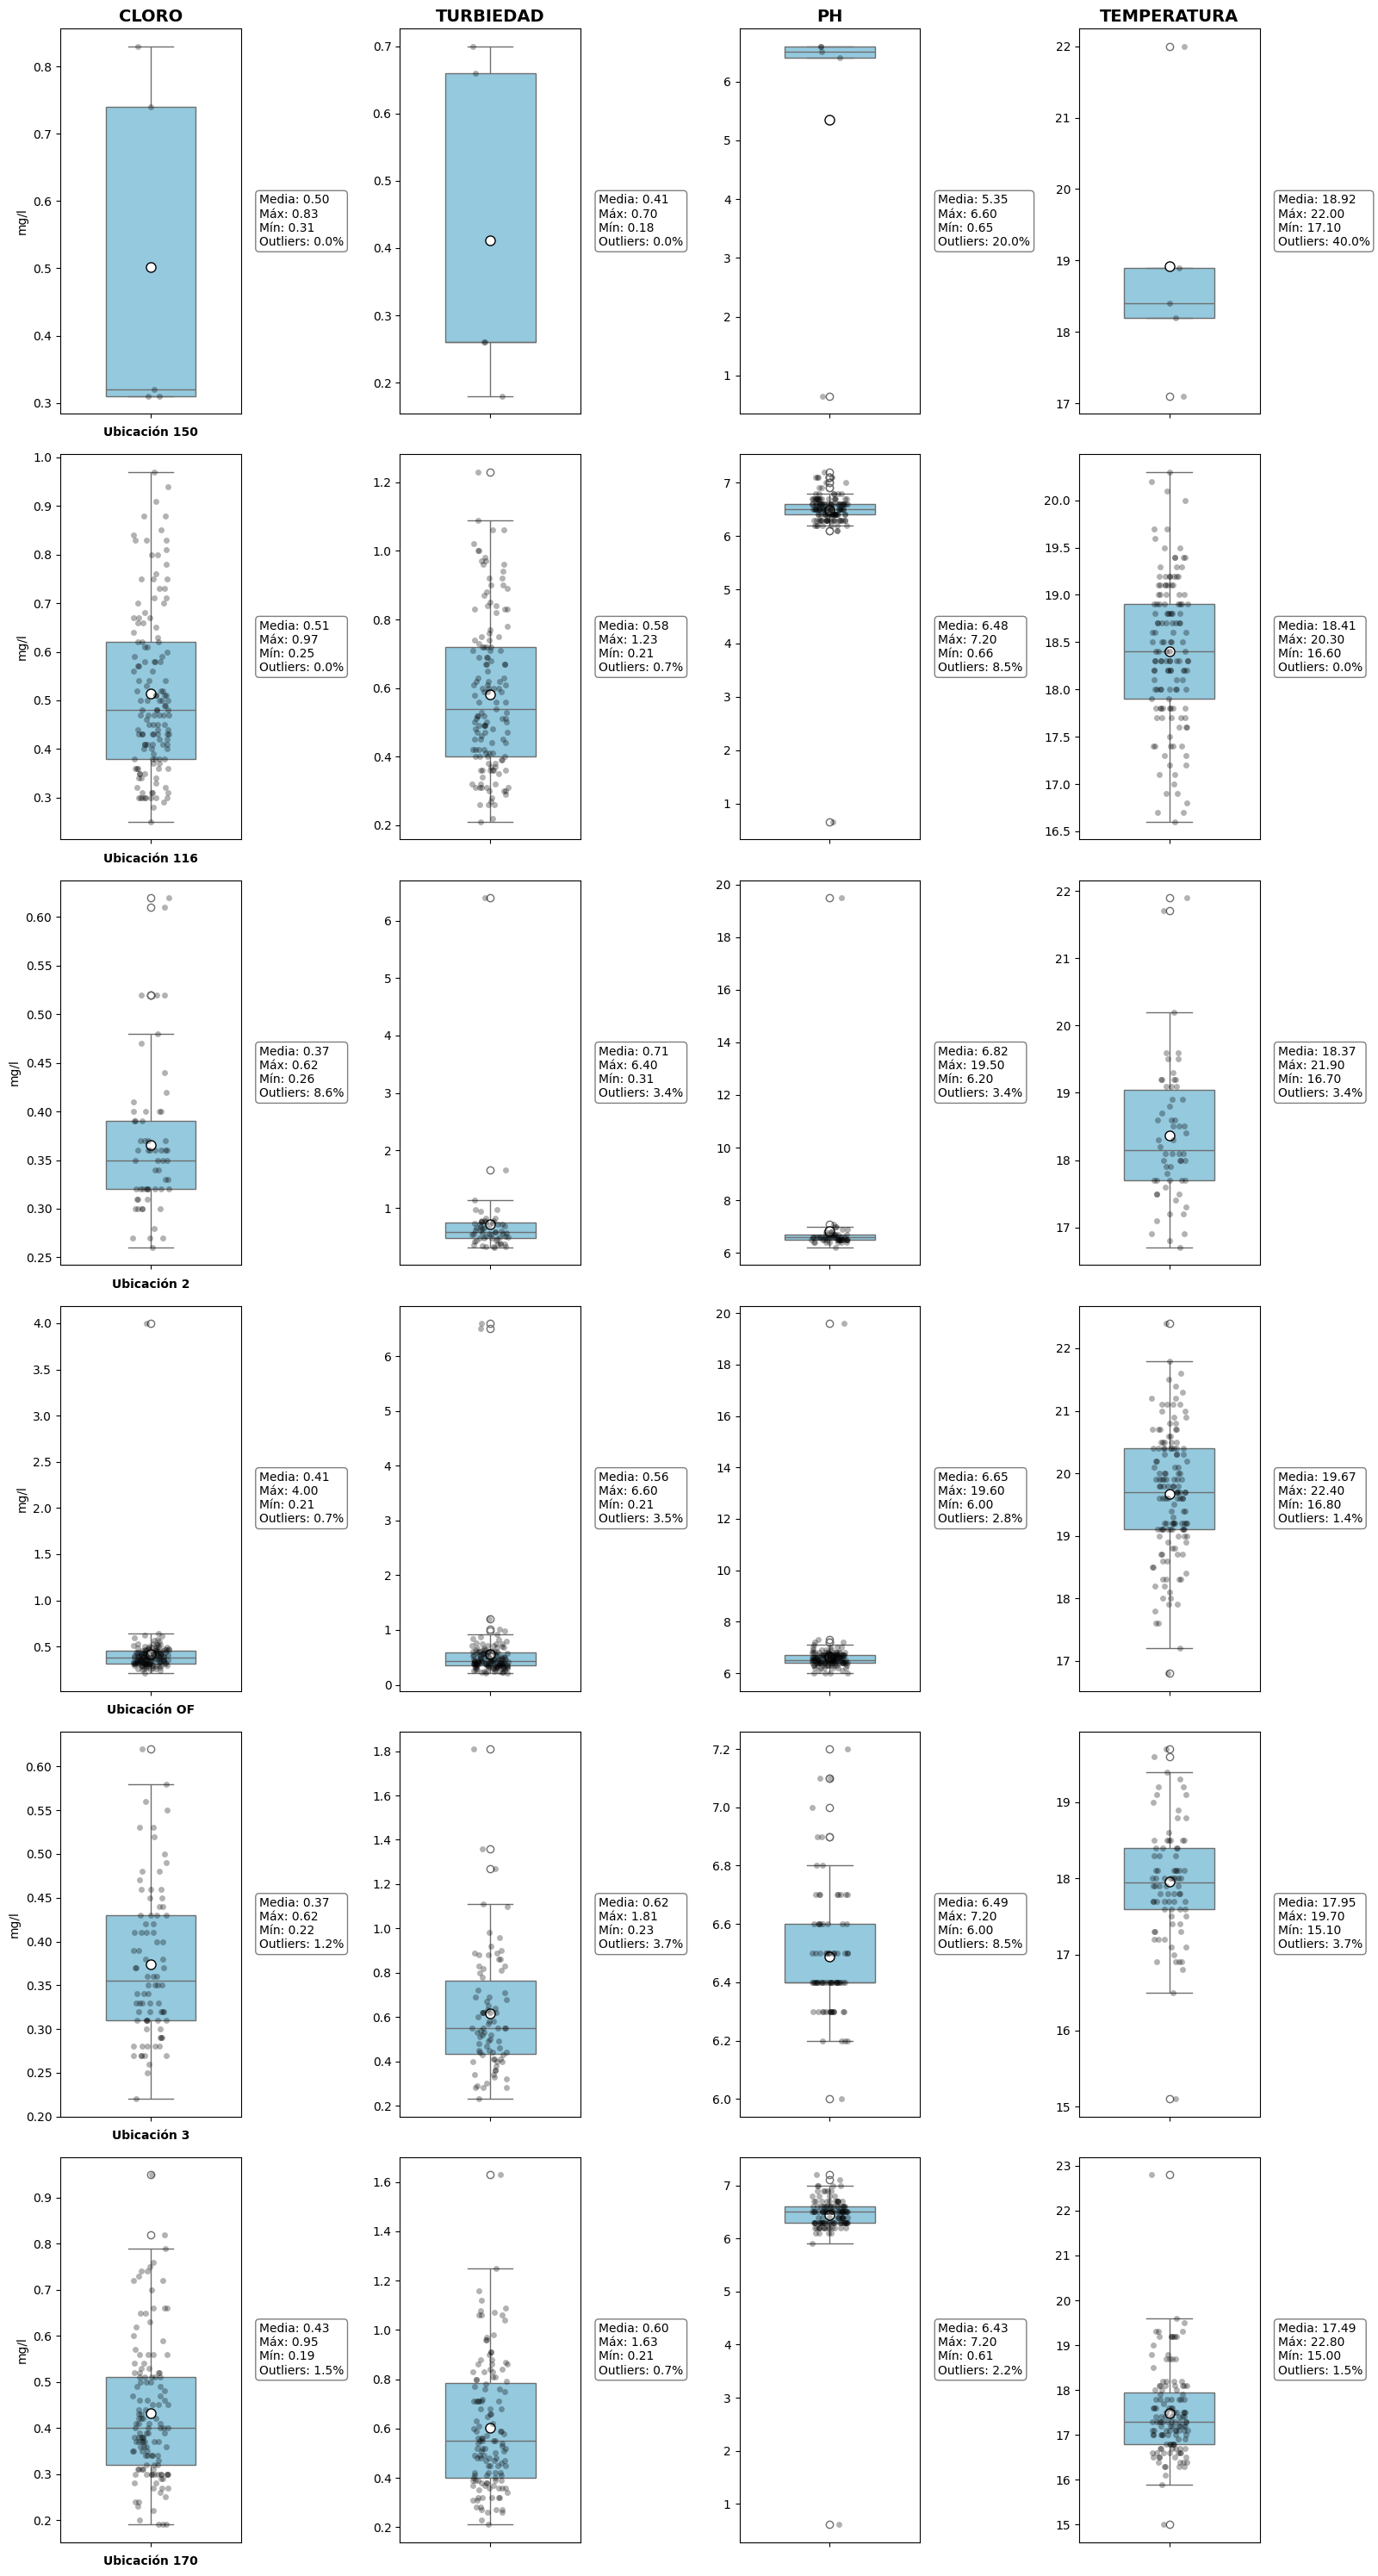

In [24]:
graficarCajas(datos)